# ENSO RL — Driver Attribution (XAI)

Driver-importance analyses: counterfactual, Shapley, driver convergence, interventional XRO, precursor composite, mutual information, integrated gradients, gradient sensitivity.

These read the per-method `.npz` files produced by the analysis scripts and do **not** depend on `inference.npz`. The behavior/lift/seasonality figures live in `analysis.ipynb`.

```bash
uv run scripts/analysis/counterfactual_analysis.py --model ensemble
uv run scripts/analysis/shapley_analysis.py        --model ensemble
uv run scripts/analysis/interventional_xro.py      --model ensemble
uv run scripts/analysis/precursor_composite.py     --model ensemble
uv run scripts/analysis/mutual_information.py      --model ensemble
uv run scripts/analysis/integrated_gradients.py    --model ensemble
uv run scripts/analysis/gradient_sensitivity.py    --model ensemble
```

## Setup

In [33]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from scipy.stats import spearmanr, ttest_1samp
from scipy.stats import t as t_dist

sys.path.insert(0, str(Path("..").resolve()))
from utils.enso_classifier import _find_continuous_runs
from utils.nb_helper import (
    PHASES, PHASE_LABELS, PHASE_COLORS, XRO_MODES, SPINUP, PHASE_MASKS,
    _zscore, _sig_stars, _add_sig_labels, _mean_ci, _load_npz,
)

NAME = "model10"   # matches --model used when running computation scripts
BASE = Path("..") / "plots" / NAME

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print(f"BASE = {BASE.resolve()}")

BASE = /Users/ayman/research/enso-rl/plots/model10


---
## 1. Counterfactual Analysis

Zero-ablation of each action dimension. ΔP(MYE) measures how much removing a mode degrades (or improves) the agent's ability to sustain multi-year ENSO.

In [34]:
cf_dir = BASE / "counterfactual"
d_cf   = _load_npz(cf_dir / "counterfactual_ensemble.npz")

features = list(d_cf["features"])  # ['WWV', 'NPMM', ...]

# Build p-values: prefer stored p_* keys; fall back to computing from per_seed
cf_pvals = {}
for p in PHASES:
    if f"p_{p}" in d_cf.files:
        cf_pvals[p] = d_cf[f"p_{p}"]
    elif f"per_seed_{p}" in d_cf.files:
        M = d_cf[f"per_seed_{p}"]  # [n_seeds, n_features]
        cf_pvals[p] = np.array([ttest_1samp(M[:, fi], 0).pvalue for fi in range(M.shape[1])])
    else:
        cf_pvals[p] = np.ones(len(features))

print(f"Features: {features}")
print(f"Phases: {list(d_cf['phases'])}")

Features: [np.str_('WWV'), np.str_('NPMM'), np.str_('SPMM'), np.str_('IOB'), np.str_('IOD'), np.str_('SIOD'), np.str_('TNA'), np.str_('ATL3'), np.str_('SASD')]
Phases: [np.str_('total'), np.str_('el_nino'), np.str_('la_nina')]


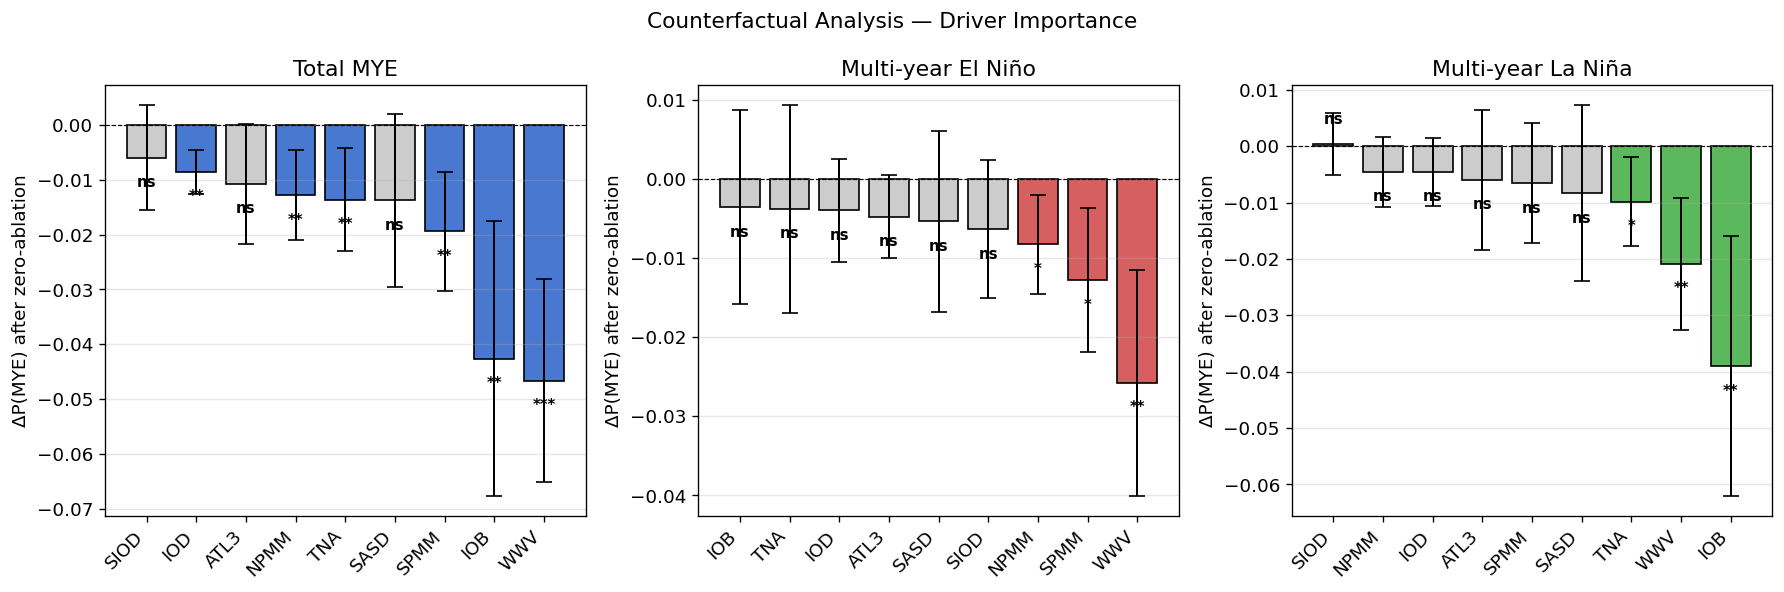

In [35]:
# --- 1. Counterfactual ΔP bars per phase ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
for ax, phase in zip(axes, PHASES):
    means = d_cf[f"mean_{phase}"]
    cis   = d_cf[f"ci_{phase}"]
    pvals = cf_pvals[phase]

    order = np.argsort(means)[::-1]
    names_s = [features[i] for i in order]
    means_s = means[order]
    cis_s   = cis[order]
    pvals_s = pvals[order]

    colors = [PHASE_COLORS[phase] if p < 0.05 else "#cccccc" for p in pvals_s]
    x = np.arange(len(features))
    ax.bar(x, means_s, color=colors, edgecolor="black", linewidth=1.0,
           yerr=cis_s, capsize=5, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    _add_sig_labels(ax, x, means_s, pvals_s)
    ax.set_xticks(x); ax.set_xticklabels(names_s, rotation=45, ha="right")
    ax.set_ylabel("ΔP(MYE) after zero-ablation")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Counterfactual Analysis — Driver Importance", fontsize=13)
fig.tight_layout()
plt.show()

---
## 2. Shapley Analysis

Permutation-based Shapley values across seeds — a game-theoretic attribution of each mode's marginal contribution to the agent's MYE lift.

In [36]:
sh_dir = BASE / "shapley"
d_sh   = _load_npz(sh_dir / "shapley_ensemble.npz")

sh_features = list(d_sh["features"])

sh_pvals = {}
for p in PHASES:
    if f"p_{p}" in d_sh.files:
        sh_pvals[p] = d_sh[f"p_{p}"]
    elif f"per_seed_{p}" in d_sh.files:
        M = d_sh[f"per_seed_{p}"]
        sh_pvals[p] = np.array([ttest_1samp(M[:, fi], 0).pvalue for fi in range(M.shape[1])])
    else:
        sh_pvals[p] = np.ones(len(sh_features))

print(f"Features: {sh_features}")

Features: [np.str_('WWV'), np.str_('NPMM'), np.str_('SPMM'), np.str_('IOB'), np.str_('IOD'), np.str_('SIOD'), np.str_('TNA'), np.str_('ATL3'), np.str_('SASD')]


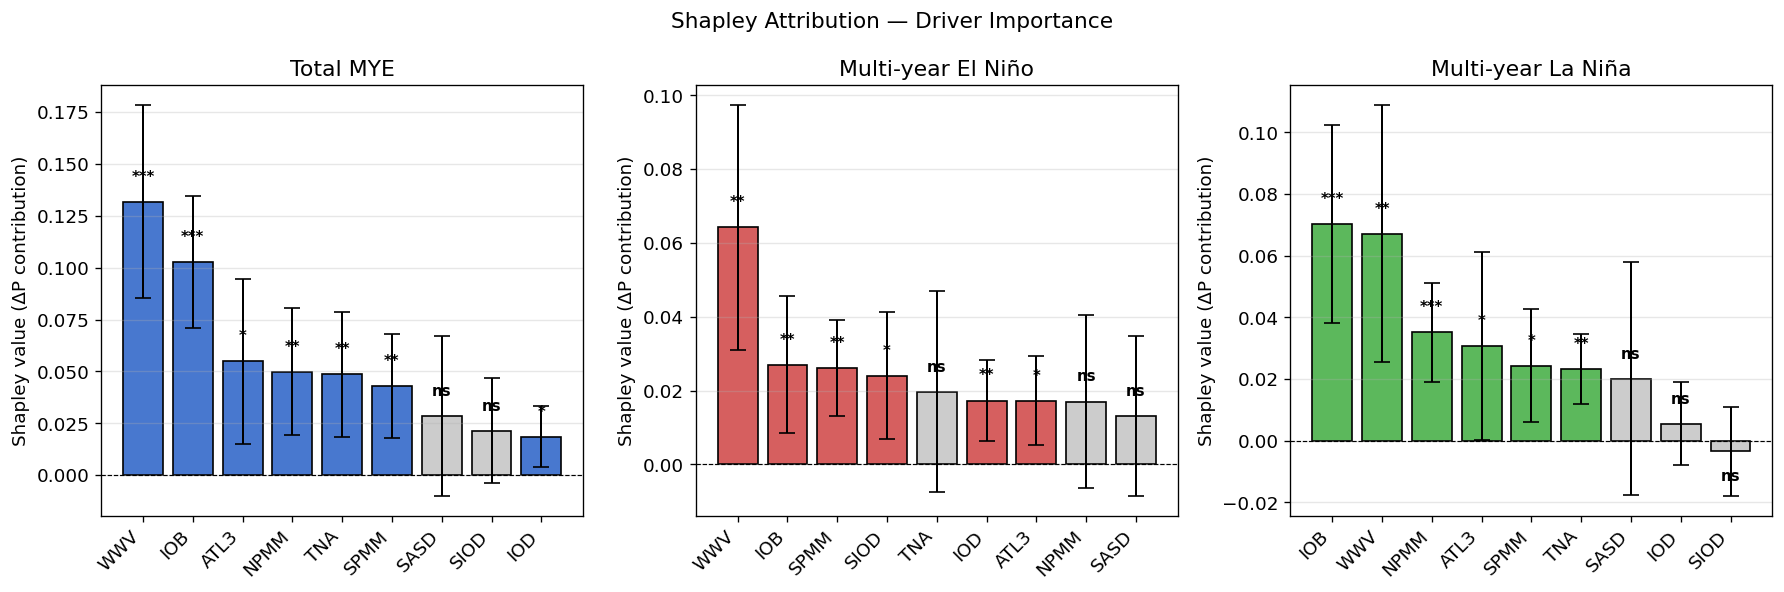

In [37]:
# --- 2a. Shapley bars per phase ---
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
for ax, phase in zip(axes, PHASES):
    means = d_sh[f"mean_{phase}"]
    cis   = d_sh[f"ci_{phase}"]
    pvals = sh_pvals[phase]

    order = np.argsort(means)[::-1]
    names_s = [sh_features[i] for i in order]
    means_s = means[order]
    cis_s   = cis[order]
    pvals_s = pvals[order]

    colors = [PHASE_COLORS[phase] if p < 0.05 else "#cccccc" for p in pvals_s]
    x = np.arange(len(sh_features))
    ax.bar(x, means_s, color=colors, edgecolor="black", linewidth=1.0,
           yerr=cis_s, capsize=5, error_kw={"linewidth": 1.2})
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    _add_sig_labels(ax, x, means_s, pvals_s)
    ax.set_xticks(x); ax.set_xticklabels(names_s, rotation=45, ha="right")
    ax.set_ylabel("Shapley value (ΔP contribution)")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Shapley Attribution — Driver Importance", fontsize=13)
fig.tight_layout()
plt.show()

---
## 3. Driver Convergence

Z-scored overlay of counterfactual, Shapley, and interventional methods. When all three agree, the driver ranking is robust. Spearman ρ quantifies cross-method consistency.

In [38]:
iv_path = BASE / "interventional_xro" / "interventional_xro.npz"
HAS_IV = iv_path.exists()   # interventional is OPTIONAL — its panels are skipped if absent

if HAS_IV:
    d_iv = _load_npz(iv_path)
    iv_targets = list(d_iv["targets"])    # e.g. 'WWV_+', 'WWV_-', ...
    iv_phases  = list(d_iv["phases"])
    iv_means   = d_iv["mean"]
    iv_signs   = list(d_iv["signs"])

    def _iv_for_phase(phase, features):
        """Return best (max absolute) ΔP per feature for a given phase from interventional."""
        vals = np.zeros(len(features))
        for i, feat in enumerate(features):
            idxs = [j for j, (t, ph) in enumerate(zip(iv_targets, iv_phases))
                    if ph == phase and t.startswith(feat)]
            if idxs:
                vals[i] = iv_means[idxs][np.argmax(np.abs(iv_means[idxs]))]
        return vals

    print(f"Interventional: {len(iv_targets)} target×phase entries")
else:
    print(f"[skip] {iv_path} not found — interventional is optional; its panels "
          "(the overlay in Section 3 and all of Section 5) are omitted.\n"
          "        Run scripts/analysis/interventional_xro.py --model <name> to include it.")

[skip] ../plots/model10/interventional_xro/interventional_xro.npz not found — interventional is optional; its panels (the overlay in Section 3 and all of Section 5) are omitted.
        Run scripts/analysis/interventional_xro.py --model <name> to include it.


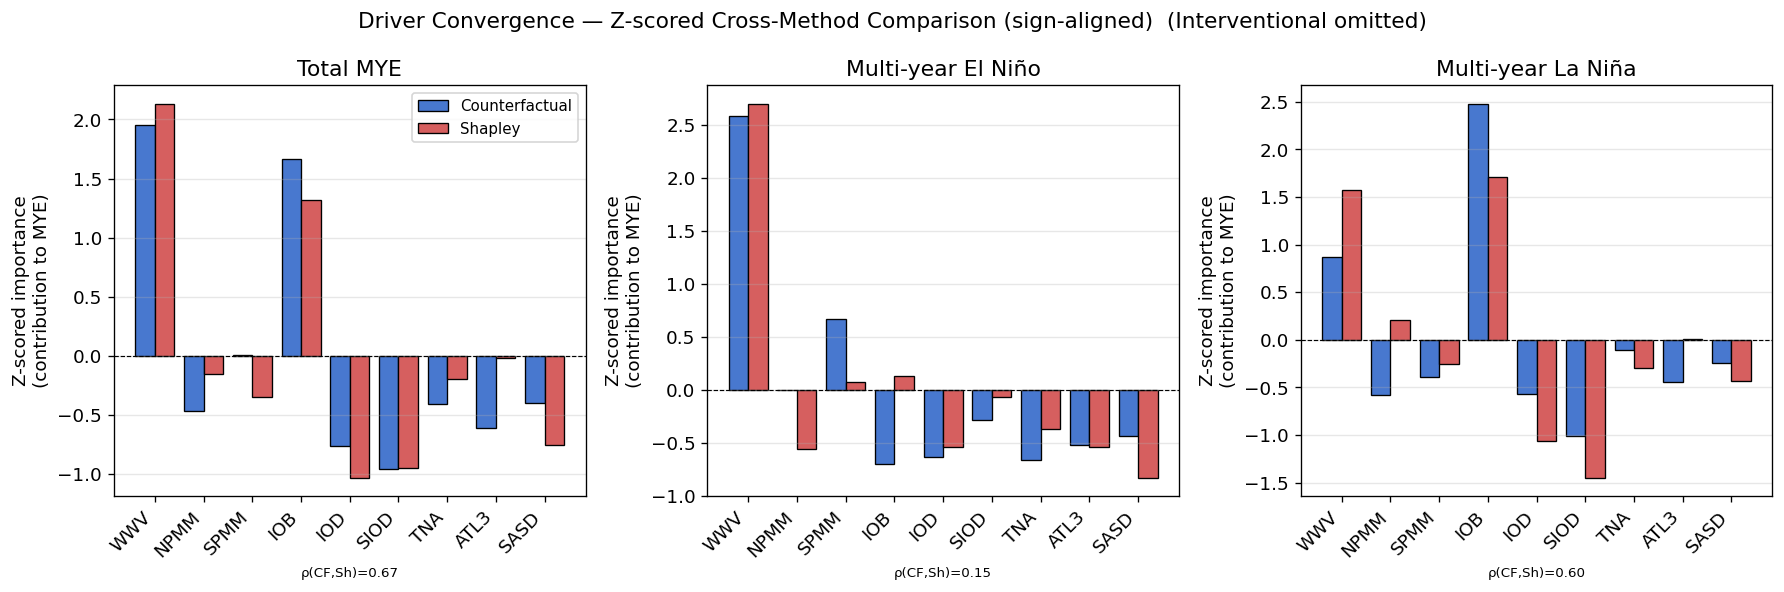

In [39]:
# --- 3. Z-scored driver convergence overlay (Interventional added only if computed) ---
# IMPORTANT sign convention: counterfactual importance is the DROP in P(MYE) when a mode
# is removed (important => large NEGATIVE ΔP), whereas Shapley/interventional express a
# POSITIVE contribution. We flip the counterfactual sign (importance = -ΔP) so all methods
# read as "contribution to MYE"; otherwise the cross-method Spearman ρ is spuriously
# negative even when the rankings agree.
fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
x = np.arange(len(features))

# Always Counterfactual + Shapley; add Interventional as a third method when available.
methods = [("Counterfactual", "#4878CF", lambda ph: _zscore(-d_cf[f"mean_{ph}"])),
           ("Shapley",        "#D65F5F", lambda ph: _zscore(d_sh[f"mean_{ph}"]))]
if HAS_IV:
    methods.append(("Interventional", "#5CB85C", lambda ph: _zscore(_iv_for_phase(ph, features))))

n_m = len(methods)
w = 0.8 / n_m
offsets = (np.arange(n_m) - (n_m - 1) / 2) * w
abbr = {"Counterfactual": "CF", "Shapley": "Sh", "Interventional": "IV"}

for ax, phase in zip(axes, PHASES):
    zvals = [fn(phase) for _, _, fn in methods]
    for (label, color, _), off, z in zip(methods, offsets, zvals):
        ax.bar(x + off, z, w, label=label, color=color, edgecolor="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_xticks(x); ax.set_xticklabels(features, rotation=45, ha="right")
    ax.set_ylabel("Z-scored importance\n(contribution to MYE)")
    ax.set_title(PHASE_LABELS[phase])
    ax.grid(axis="y", alpha=0.3)

    # Spearman ρ across each available method pair (on sign-aligned importances)
    rhos = [f"ρ({abbr[methods[a][0]]},{abbr[methods[b][0]]})={spearmanr(zvals[a], zvals[b])[0]:.2f}"
            for a in range(n_m) for b in range(a + 1, n_m)]
    ax.set_xlabel("  ".join(rhos), fontsize=8)

axes[0].legend(fontsize=9)
fig.suptitle("Driver Convergence — Z-scored Cross-Method Comparison (sign-aligned)"
             + ("" if HAS_IV else "  (Interventional omitted)"), fontsize=13)
fig.tight_layout()
plt.show()

---
## 4. Seed Sensitivity — Driver Stability

Per-seed counterfactual & Shapley driver rankings — checks whether attribution is stable across seeds.

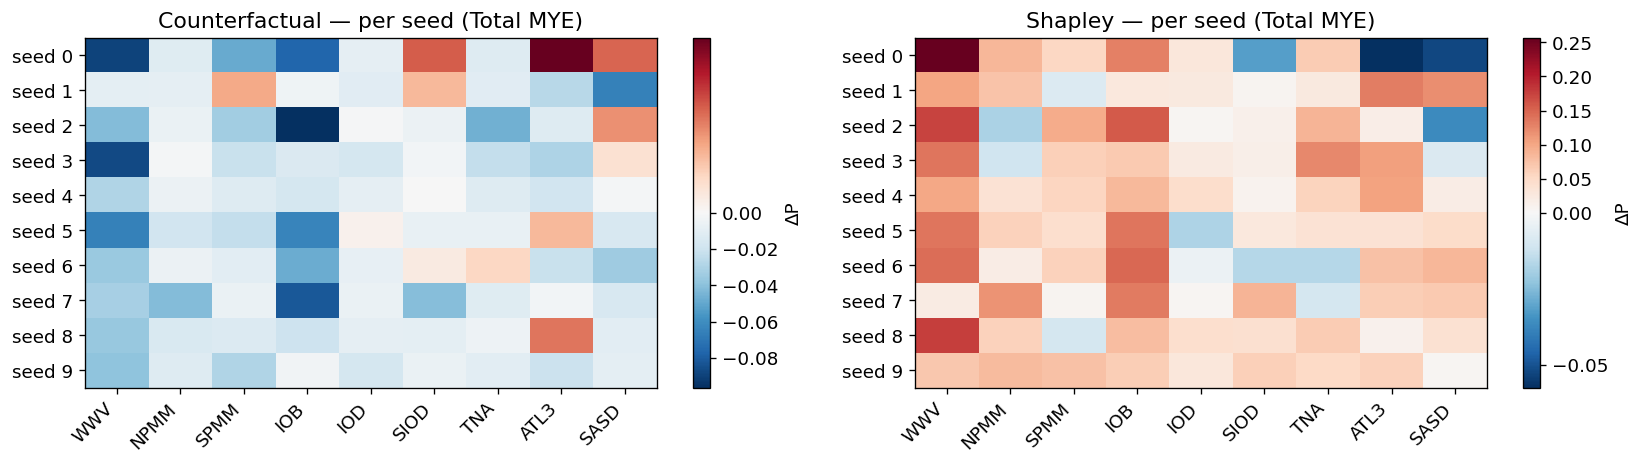

In [40]:
# --- 4. Seed × mode heatmaps (CF and Shapley, total phase) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (d, label) in zip(axes, [(d_cf, "Counterfactual"), (d_sh, "Shapley")]):
    if "per_seed_total" in d.files:
        M = d["per_seed_total"]   # [n_seeds, n_features]
        feat = list(d["features"])
        im = ax.imshow(M, cmap="RdBu_r", aspect="auto",
                       norm=mcolors.TwoSlopeNorm(vcenter=0))
        ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=45, ha="right")
        ax.set_yticks(range(M.shape[0])); ax.set_yticklabels([f"seed {i}" for i in range(M.shape[0])])
        ax.set_title(f"{label} — per seed (Total MYE)")
        plt.colorbar(im, ax=ax, label="ΔP")
    else:
        ax.text(0.5, 0.5, f"per_seed_total\nnot in {label} npz\n(re-run script)",
                ha="center", va="center", transform=ax.transAxes, fontsize=10)
        ax.set_title(f"{label} — per seed (Total MYE)")

fig.tight_layout()
plt.show()

---
## 5. Interventional XRO

Direct mode-press and mode-brake interventions in a free XRO. Shows which modes, when externally sustained or suppressed, causally change MYE probability.

In [41]:
# interventional_xro.npz keys: targets, signs, phases, mean, ci, p
if HAS_IV:
    iv_df = pd.DataFrame({
        "target": list(d_iv["targets"]),
        "sign":   list(d_iv["signs"]),
        "phase":  list(d_iv["phases"]),
        "mean":   d_iv["mean"],
        "ci":     d_iv["ci"],
        "p":      d_iv["p"] if "p" in d_iv.files else np.ones(len(d_iv["targets"])),
    })
    # Extract mode name (everything before last _)
    iv_df["mode"] = iv_df["target"].str.rsplit("_", n=1).str[0]
    print(iv_df.head(6).to_string())
else:
    print("[skip] Interventional not computed — Section 5 omitted.")

[skip] Interventional not computed — Section 5 omitted.


In [42]:
# --- 5. Interventional ΔP bars per phase ---
if HAS_IV:
    fig, axes = plt.subplots(1, len(PHASES), figsize=(15, 5), sharey=False)
    for ax, phase in zip(axes, PHASES):
        sub = iv_df[iv_df["phase"] == phase].copy()
        sub = sub.sort_values("mean", ascending=False)

        colors = ["#D65F5F" if s == "+" else "#4878CF" for s in sub["sign"]]
        colors = [c if p < 0.05 else "#cccccc" for c, p in zip(colors, sub["p"])]

        x = np.arange(len(sub))
        ax.bar(x, sub["mean"], color=colors, edgecolor="black", linewidth=0.8,
               yerr=sub["ci"], capsize=5, error_kw={"linewidth": 1.2})
        ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
        _add_sig_labels(ax, x, sub["mean"].values, sub["p"].values)
        ax.set_xticks(x); ax.set_xticklabels(sub["target"], rotation=45, ha="right", fontsize=8)
        ax.set_ylabel("ΔP(MYE)")
        ax.set_title(PHASE_LABELS[phase])
        ax.grid(axis="y", alpha=0.3)

    from matplotlib.patches import Patch
    legend_els = [Patch(facecolor="#D65F5F", label="Sustain (+)"),
                  Patch(facecolor="#4878CF", label="Brake (−)"),
                  Patch(facecolor="#cccccc", label="ns")]
    axes[0].legend(handles=legend_els, fontsize=9)
    fig.suptitle("Interventional XRO — Mode-Specific Causal Effect", fontsize=13)
    fig.tight_layout()
    plt.show()
else:
    print("[skip] Interventional XRO figure omitted (no interventional_xro.npz).")

[skip] Interventional XRO figure omitted (no interventional_xro.npz).


---
## 8. Integrated Gradients

Axiomatic attribution — IG sums exactly to the output difference (completeness). Shows which observations the policy and value function attend to.

> Run `uv run scripts/analysis/integrated_gradients.py --model ensemble` to generate `ig_results.npz`.

In [43]:
ig_path = BASE / "integrated_gradients" / "ig_results.npz"
if not ig_path.exists():
    print(f"[skip] {ig_path} not found. Run integrated_gradients.py first.")
else:
    d_ig = _load_npz(ig_path)
    policy_imp = d_ig["policy_importance_per_run"]  # [n_runs, n_obs]
    value_imp  = d_ig["value_importance_per_run"]
    obs_names  = list(d_ig["obs_names"])
    n_runs_ig  = int(d_ig["n_runs"])

    pol_mean = policy_imp.mean(axis=0)
    val_mean = value_imp.mean(axis=0)
    pol_pvals = np.array([ttest_1samp(policy_imp[:, i], 0).pvalue for i in range(policy_imp.shape[1])])
    val_pvals = np.array([ttest_1samp(value_imp[:, i],  0).pvalue for i in range(value_imp.shape[1])])

    print(f"N_runs={n_runs_ig}  |  {len(obs_names)} obs dimensions")

[skip] ../plots/model10/integrated_gradients/ig_results.npz not found. Run integrated_gradients.py first.


In [44]:
if ig_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (mean_v, pvals_v, title) in zip(axes, [
        (pol_mean, pol_pvals, "Policy IG Attribution  (Σ|IG| across actions)"),
        (val_mean, val_pvals, "Value IG Attribution  (|IG(V, obs)|)"),
    ]):
        order = np.argsort(mean_v)[::-1]
        x = np.arange(len(obs_names))
        ci95 = 1.96 * policy_imp.std(axis=0, ddof=1) / np.sqrt(n_runs_ig)
        colors = ["#4878CF" if pvals_v[i] < 0.05 else "#cccccc" for i in order]
        ax.bar(x, mean_v[order], color=colors, edgecolor="black", linewidth=0.8,
               yerr=ci95[order], capsize=5, error_kw={"linewidth": 1.2})
        _add_sig_labels(ax, x, mean_v[order], pvals_v[order])
        ax.set_xticks(x); ax.set_xticklabels([obs_names[i] for i in order], rotation=45, ha="right")
        ax.set_title(title); ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Integrated Gradients", fontsize=13)
    fig.tight_layout()
    plt.show()

---
## 9. Gradient Sensitivity

Policy Jacobian (∂action/∂obs) and value gradient (∂V/∂obs) — how much each observation dimension moves the policy output or value estimate.

> Run `uv run scripts/analysis/gradient_sensitivity.py --model ensemble` to generate `gradient_results.npz`.

In [45]:
gs_path = BASE / "gradient_sensitivity" / "gradient_results.npz"
if not gs_path.exists():
    print(f"[skip] {gs_path} not found. Run gradient_sensitivity.py first.")
else:
    d_gs = _load_npz(gs_path)
    gs_policy = d_gs["policy_importance_per_run"]  # [n_runs, n_obs]
    gs_value  = d_gs["value_importance_per_run"]
    gs_jac    = d_gs["mean_jacobian_all"]            # [n_actions, n_obs]
    gs_obs    = list(d_gs["obs_names"])
    gs_act    = list(d_gs["action_names"])
    n_runs_gs = int(d_gs["n_runs"])

    gs_pol_mean  = gs_policy.mean(axis=0)
    gs_val_mean  = gs_value.mean(axis=0)
    gs_pol_pvals = np.array([ttest_1samp(gs_policy[:, i], 0).pvalue for i in range(gs_policy.shape[1])])
    gs_val_pvals = np.array([ttest_1samp(gs_value[:, i],  0).pvalue for i in range(gs_value.shape[1])])
    print(f"N_runs={n_runs_gs}  |  obs: {len(gs_obs)}  |  actions: {len(gs_act)}")

[skip] ../plots/model10/gradient_sensitivity/gradient_results.npz not found. Run gradient_sensitivity.py first.


In [46]:
if gs_path.exists():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (mean_v, pvals_v, label) in zip(axes, [
        (gs_pol_mean, gs_pol_pvals, "Policy Sensitivity  (Σ|∂a/∂o|)"),
        (gs_val_mean, gs_val_pvals, "Value Sensitivity  (|∂V/∂o|)"),
    ]):
        order = np.argsort(mean_v)[::-1]
        x = np.arange(len(gs_obs))
        ci95 = 1.96 * gs_policy.std(axis=0, ddof=1) / np.sqrt(n_runs_gs)
        colors = ["#4878CF" if pvals_v[i] < 0.05 else "#cccccc" for i in order]
        ax.bar(x, mean_v[order], color=colors, edgecolor="black", linewidth=0.8,
               yerr=ci95[order], capsize=5, error_kw={"linewidth": 1.2})
        _add_sig_labels(ax, x, mean_v[order], pvals_v[order])
        ax.set_xticks(x); ax.set_xticklabels([gs_obs[i] for i in order], rotation=45, ha="right")
        ax.set_title(label); ax.grid(axis="y", alpha=0.3)

    fig.suptitle("Gradient-Based Sensitivity", fontsize=13)
    fig.tight_layout()
    plt.show()

In [47]:
if gs_path.exists():
    # Policy Jacobian heatmap |∂action/∂obs|
    fig, ax = plt.subplots(figsize=(12, 5))
    im = ax.imshow(gs_jac[:, :len(gs_obs)], cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(gs_obs))); ax.set_xticklabels(gs_obs, rotation=45, ha="right")
    ax.set_yticks(range(len(gs_act))); ax.set_yticklabels(gs_act)
    ax.set_xlabel("Observation"); ax.set_ylabel("Action")
    ax.set_title("Policy Jacobian: Mean |∂action/∂observation|")
    plt.colorbar(im, ax=ax)

    for i in range(gs_jac.shape[0]):
        for j in range(min(gs_jac.shape[1], len(gs_obs))):
            val = gs_jac[i, j]
            color = "white" if val > gs_jac.max() * 0.6 else "black"
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7, color=color)

    fig.tight_layout()
    plt.show()